The narrative, case studies, and terminology are adapted from that chapter for classroom use.
The code demonstrations are written for this course: they depend only on `numpy`, `pandas`, and `matplotlib`, so every cell runs on a bare Python install. 
An **optional** cell at the end reproduces the book's own `statsforecast` workflow for students who want the Nixtla stack.


# Learning outcomes

By the end of this lecture you should be able to:

1. **Judge forecastability.** State the four conditions that govern how well a quantity can be forecast, and apply them to decide whether a proposed forecasting project is viable at all.
2. **Separate three ideas that are routinely confused.**  *Forecasting*, *goals*, and *planning* and explain why an organization that conflates them keeps missing its targets.
3. **Scope a forecasting problem:** choose the aggregation level, the forecast horizon, and the update frequency, and identify stakeholders *before* touching any data.
4. **Distinguish model families:** qualitative vs. quantitative; pure time series models vs. explanatory (causal) models vs. mixed models, and defend a choice among them.
5. **Execute the five basic steps** of a forecasting task end to end on a real dataset.
6. **Adopt the statistical perspective:** treat a forecast as a *probability distribution*, not a number; produce and read point forecasts and prediction intervals; use the notation $\hat{y}_{T+h\mid T}$ correctly.



---
# Setup

Everything below needs only `numpy`, `pandas`, and `matplotlib`. If one is missing, uncomment and
run the install line.


In [1]:
# !pip install numpy pandas matplotlib

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Reproducibility: every simulation in this notebook draws from this one generator.
SEED = 1
RNG = np.random.default_rng(SEED)

np.set_printoptions(suppress=True)
pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 100)

plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.facecolor": "white",
    "axes.edgecolor": "0.4",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "grid.alpha": 0.35,
    "grid.color": "0.7",
})

# A restrained, colour-blind-safe palette, used consistently throughout.
C_HIST, C_FC, C_ALT, C_ACT = "#1a1a1a", "#2f2fff", "#d95f02", "#009e73"

print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"matplotlib {mpl.__version__}")

numpy      2.3.2
pandas     2.3.3
matplotlib 3.10.6


## Data

Both datasets come straight from the book's data directory and are cached locally on first use, so
the notebook works offline afterwards. If you have no internet in class, download
[`fpppy_data.zip`](https://otexts.com/fpppy/data/fpppy_data.zip) beforehand and unzip it into a
`data/` folder next to this notebook.

| File | Contents                                                                                        | Used in |
|---|-------------------------------------------------------------------------------------------------|---|
| `aus_production.csv` | Australian quarterly production, such as beer, tobacco, bricks, cement, electricity, gas; 1956Q1–2010Q2 | Demos 2, 3 |
| `austa.csv` | Total annual international visitor arrivals to Australia (millions); 1980–2015                  | Demos 4, 5 |


In [2]:
import urllib.request

BOOK_DATA_URL = "https://otexts.com/fpppy/data/"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


def load_book_csv(name, **kwargs):
    """Load a dataset from the fpppy website, caching it in ./data/ on first use.

    The site rejects Python's default user agent, so we fetch the bytes ourselves
    with a browser-like header rather than handing the URL straight to pandas.
    """
    local = DATA_DIR / name
    if not local.exists():
        request = urllib.request.Request(BOOK_DATA_URL + name,
                                         headers={"User-Agent": "Mozilla/5.0"})
        try:
            with urllib.request.urlopen(request, timeout=30) as response:
                local.write_bytes(response.read())
        except Exception as err:                  # offline, proxy, or firewall
            raise RuntimeError(
                f"Could not download '{name}'. Download "
                f"https://otexts.com/fpppy/data/fpppy_data.zip and unzip it into {DATA_DIR.resolve()}"
            ) from err
    return pd.read_csv(local, **kwargs)


aus_production = load_book_csv("aus_production.csv", parse_dates=["ds"])
austa = load_book_csv("austa.csv")

print("aus_production:", aus_production.shape, "|",
      aus_production["ds"].min().date(), "to", aus_production["ds"].max().date())
print("austa:         ", austa.shape, "|",
      int(austa["Year"].min()), "to", int(austa["Year"].max()))
aus_production.head()


aus_production: (218, 7) | 1956-01-01 to 2010-04-01
austa:          (36, 2) | 1980 to 2015


,ds,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956-01-01,284,5225.0,189.0,465,3923,5
1,1956-04-01,213,5178.0,204.0,532,4436,6
2,1956-07-01,227,5297.0,208.0,561,4806,7
3,1956-10-01,308,5681.0,197.0,570,4418,6
4,1957-01-01,262,5577.0,187.0,529,4339,5


---
# What can be forecast?  

Forecasting is old, e.g., Babylonian soothsayers, the Oracle at Delphi, and occasionally illegal:
Emperor Constantius II banned consulting fortune-tellers in AD 357; England outlawed it in 1824.
What has changed is not the demand for forecasts but our ability to *quantify how much to trust one*.

The engineering question is therefore never "can we forecast?" but **"how predictable is this
quantity?"** That depends on four things:

> ### The four conditions of predictability
>
> 1. **How well we understand the factors that contribute to the outcome.**
> 2. **How much data are available.**
> 3. **How similar the future is to the past** whether the mechanism that generated the history still operates.
> 4. **Whether the forecast itself can affect the thing being forecast** (a feedback loop).

## A tale of two forecasts

| | Short-term residential **electricity demand**    | **Exchange rate** movements                      |
|---|--------------------------------------------------|--------------------------------------------------|
| Understanding of drivers | Strong: temperature, time of day, day of week    | Weak                                             |
| Data availability | Decades of high-frequency data ✔                 | Plentiful ✔                                      |
| Future resembles past | Yes, over a 1–3 day horizon ✔                    | Not necessarily. The next crisis is a new crisis |
| Free of feedback | Yes. Residential price is not demand-dependent ✔ | **No** Published forecasts move the market       |
| **Result** | Highly accurate short-term forecasts             | **No better than chance**                        |

The exchange-rate case satisfies only condition 2. Under the efficient market hypothesis the best
available forecast of tomorrow's rate is *today's rate*, e.g., the **naïve method**. Any model that
appears to beat it out-of-sample deserves deep suspicion, and usually a data-leakage audit.

## The most common misconception

> "Forecasting only works if things don't change."

Wrong, and worth stating precisely: a good forecasting model **captures the way in which things are
changing**, and assumes that *the pattern of change* continues. A volatile market is forecast to stay
volatile; an economy with business cycles is forecast to keep cycling. What breaks a forecast is not
change. It is a change in *the nature of the change*.

## The method spectrum

`naïve` → `seasonal naïve` → `exponential smoothing (ETS)` → `ARIMA` → `dynamic regression` →
`hierarchical reconciliation` → `neural networks` / `foundation models`

A theme of this course: **the simple methods are the benchmarks everything else must beat**, and they
win far more often than the literature admits.


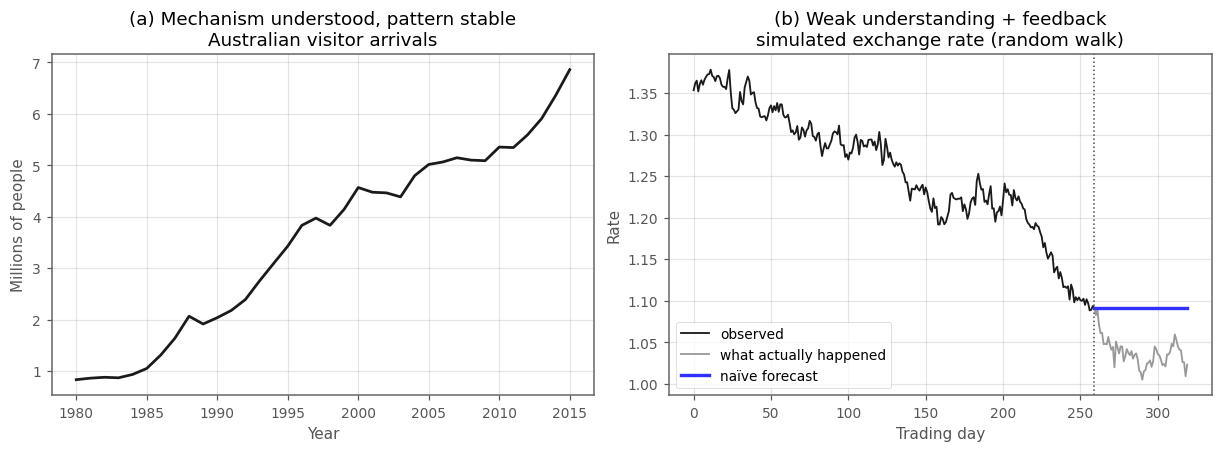

Visitor arrivals   RMSE(naive) =  0.2534   RMSE(mean) =  1.8084   ratio =  0.14
Random walk        RMSE(naive) =  0.0091   RMSE(mean) =  0.0746   ratio =  0.12


In [3]:
# Demo 1 — predictability is a property of the process, not of the model.
#
# Left  : Australian international visitor arrivals -- a driven, persistent mechanism.
# Right : a simulated random walk (exchange-rate analogue), where the naive forecast
#         (a flat line at the last observation) is provably the best you can do.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(austa["Year"], austa["Visitors"], color=C_HIST, lw=1.8)
ax.set_title("(a) Mechanism understood, pattern stable\nAustralian visitor arrivals")
ax.set_xlabel("Year")
ax.set_ylabel("Millions of people")

ax = axes[1]
n_hist, n_future = 260, 60
walk = 1.35 + np.cumsum(RNG.normal(0.0, 0.01, n_hist + n_future))
t = np.arange(n_hist + n_future)

ax.plot(t[:n_hist], walk[:n_hist], color=C_HIST, lw=1.2, label="observed")
ax.plot(t[n_hist - 1:], walk[n_hist - 1:], color="0.6", lw=1.2, label="what actually happened")
ax.plot(t[n_hist - 1:], np.repeat(walk[n_hist - 1], n_future + 1), color=C_FC, lw=2.2,
        label="naïve forecast")
ax.axvline(n_hist - 1, color="0.3", ls=":", lw=1)
ax.set_title("(b) Weak understanding + feedback\nsimulated exchange rate (random walk)")
ax.set_xlabel("Trading day")
ax.set_ylabel("Rate")
ax.legend(loc="best", frameon=True)

plt.show()


def naive_skill(y):
    """One-step naive RMSE vs. the RMSE of always forecasting the historical mean."""
    y = np.asarray(y, dtype=float)
    rmse_naive = np.sqrt(np.mean(np.diff(y) ** 2))
    rmse_mean = np.std(y, ddof=1)
    return rmse_naive, rmse_mean


for label, series in [("Visitor arrivals", austa["Visitors"]), ("Random walk", walk[:n_hist])]:
    rn, rm = naive_skill(series)
    print(f"{label:<18} RMSE(naive) = {rn:7.4f}   RMSE(mean) = {rm:7.4f}   ratio = {rn / rm:5.2f}")


**Read that output carefully.** For the random walk the naïve method crushes the historical mean, yet the forecast is a *flat line*. We can predict the level one step ahead and nothing beyond it. A small error is not the same as a useful forecast. 


**Discussion.** Rank these from *most* to *least* forecastable and name the binding constraint, which of the four conditions fails first:

1. Vibration amplitude of a wind-turbine gearbox 10 minutes ahead
2. Peak electricity demand for Mississippi next July
3. The closing price of one stock tomorrow
4. Enrollment in ME 8990 next fall
5. Remaining useful life of a bearing under an *unknown* future load profile
6. The time of tomorrow's sunrise


---
# Forecasting, goals, and planning 

Three words used interchangeably in industry meetings, with expensive consequences:

| | Definition | Question it answers | Failure mode |
|---|---|---|---|
| **Forecasting** | Predicting the future as accurately as possible, given all information available — history *and* knowledge of future events | *What will happen?* | Wishful thinking dressed as analysis |
| **Goals** | What you would *like* to happen | *What do we want?* | Set with no forecast and no plan — so nothing connects them |
| **Planning** | The response to forecasts and goals: the actions that make the forecast meet the goal | *What will we do about it?* | Plans built on goals instead of forecasts |

The pathology to recognize: a target is announced ("15 % growth"), no forecast is produced, no plan links the two, and the target is missed. **A goal is not a forecast, and a forecast is not a plan.**
When a stakeholder pushes back on a forecast because "that number is too low," they are asking you to change a *forecast* to match a *goal*. That request must be refused — the correct response is to change the *plan*.

### Horizons drive everything

| Horizon | Typical decisions | Data needed | Typical methods |
|---|---|---|---|
| **Short-term** (days–weeks) | Scheduling personnel, production, transportation | High-frequency, item-level | ETS, ARIMA, automated pipelines |
| **Medium-term** (months–~1 yr) | Purchasing raw materials, hiring, buying equipment | Aggregated demand | ETS/ARIMA + explanatory variables |
| **Long-term** (years) | Strategic planning, capacity, market entry | Aggregate + external drivers | Scenario / judgmental / econometric |

The horizon determines the aggregation level, the model class, the achievable accuracy, and who owns
the decision. Fix it first.

An organization that forecasts well needs three things at once: (i) a *system* that supports several methods, (ii) *expertise* in framing problems and selecting methods, and (iii) *organizational commitment* to using the forecasts it produces. Missing any one of the three, the other two are wasted.


---
# Determining what to forecast 

Before any modelling, settle these. Getting them wrong is far more costly than choosing a suboptimal
model later.

**1. What is the forecast unit?** For a manufacturer, forecasts might be needed for
- every product line, or every product *group*;
- every retail outlet, outlets grouped by region, or total sales only;
- weekly, monthly, or annual data.

**2. Forecast horizon.** One month ahead? Six months? Ten years? Different horizons demand different
models. This is not a parameter you tune at the end.

**3. Update frequency.** Forecasts needed once a year can be produced by hand and scrutinized.
Forecasts needed every week for 5,000 SKUs must be **automatic, robust, and unattended**, which rules
out anything requiring per-series human judgment.

**4. Who uses the forecast, and for what decision?** Talk to them *before* you build. A forecast whose
error distribution does not match the cost structure of the decision it feeds is a wasted model.

> ### The unglamorous reality
> A large share of a forecaster's time goes to **locating and assembling the data**, not modelling.
> The data may live in company records, a demand database maintained by someone in another division,
> or public statistics. Budget for this. In practice, expect the split to be roughly
> 60 % data wrangling / 20 % modelling / 20 % communicating.

**Discussion.** You are asked to "forecast maintenance costs for the plant." Write down the
four decisions above as *specific* choices. Notice how many different, incompatible projects that one
sentence permits.


---
# Forecasting data and methods

## Qualitative vs. quantitative

**Qualitative forecasting** applies when *no relevant data are available*, or the data are irrelevant
to the forecast at hand (a brand-new product, an unprecedented regulation). These are not guesses:
there are well-structured, well-documented methods, e.g., Delphi, analogy, scenario building.

**Quantitative forecasting** applies when **both** of these hold:

1. numerical information about the past is available, **and**
2. it is reasonable to assume that some aspects of the past pattern will continue.

Condition 2 is an *assumption*, not a fact. Stating it explicitly is part of the deliverable.

## Time series data

A **time series** is a sequence of observations recorded at regular intervals:

| Frequency | Example |
|---|---|
| Annual | Google's annual profits |
| Quarterly | Amazon's quarterly sales results |
| Monthly | Monthly rainfall |
| Weekly | Weekly retail sales |
| Daily | Daily IBM stock prices |
| Hourly | Hourly electricity demand |
| 5-minute | Freeway traffic counts |

This course treats **regularly spaced** series only. Irregularly spaced observations, such as time-stamped stock transaction data, event logs, form their own field and are out of scope (though we note where
resampling can rescue them).

When forecasting a time series with a pure time series method, we use **only the variable's own history**: we extrapolate trend and seasonality and deliberately ignore marketing, competitor moves,
and the economy. That sounds like a weakness.

**Decomposition methods** separate trend and seasonality for inspection;
**exponential smoothing** and **ARIMA** are the two workhorse quantitative families.

## Demo 2: a time series forecast, the way the book presents it

Below we reproduce the spirit of the book's Figure 1.1: Australian quarterly beer production with two years of forecasts, an 80 % interval (dark band) and a 95 % interval (light band).

The method is **seasonal naïve**: the forecast for each quarter is simply the value observed in the same quarter of the last year. It is a *benchmark* — but on strongly seasonal data with no trend it is a demanding one.

$$\hat{y}_{T+h\mid T} = y_{T+h-m(k+1)}, \qquad k = \left\lfloor \frac{h-1}{m} \right\rfloor$$

where $m = 4$ is the seasonal period. Its $h$-step forecast standard deviation grows like
$\hat\sigma\sqrt{k+1}$ is uncertainty widens with the horizon, but only as a step function of the
number of complete seasonal cycles ahead.


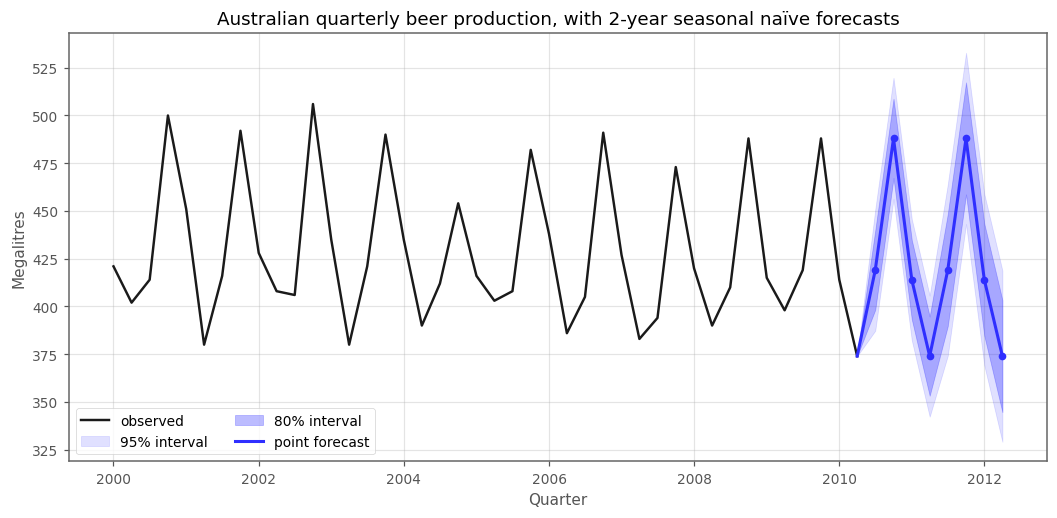

,ds,forecast,lo80,hi80,lo95,hi95
0,2010Q3,419.0,398.3,439.7,387.3,450.7
1,2010Q4,488.0,467.3,508.7,456.3,519.7
2,2011Q1,414.0,393.3,434.7,382.3,445.7
3,2011Q2,374.0,353.3,394.7,342.3,405.7
4,2011Q3,419.0,389.7,448.3,374.2,463.8
5,2011Q4,488.0,458.7,517.3,443.2,532.8
6,2012Q1,414.0,384.7,443.3,369.2,458.8
7,2012Q2,374.0,344.7,403.3,329.2,418.8


In [4]:
#Demo 2 — Australian quarterly beer production, with prediction intervals (cf. book Fig. 1.1).

beer = (aus_production.loc[aus_production["ds"] >= "1992-01-01", ["ds", "Beer"]]
        .dropna()
        .reset_index(drop=True))

M = 4                       # quarterly data -> seasonal period 4
Z = {80: 1.2816, 95: 1.9600}   # normal quantiles; no scipy needed


def seasonal_naive(y, h, m=M):
    """Point forecasts and Gaussian prediction intervals for the seasonal naive method."""
    y = np.asarray(y, dtype=float)
    T = len(y)
    steps = np.arange(1, h + 1)
    k = (steps - 1) // m                                  # complete seasonal cycles ahead
    point = y[T + steps - m * (k + 1) - 1]                # value in the same quarter, k+1 years back

    resid = y[m:] - y[:-m]                                # one-step-ahead seasonal naive residuals
    sigma = np.std(resid, ddof=1)
    sd = sigma * np.sqrt(k + 1)                           # h-step forecast standard deviation
    return point, sd


H = 8                                                     # two years ahead
point, sd = seasonal_naive(beer["Beer"], H)
future = pd.date_range(beer["ds"].iloc[-1], periods=H + 1, freq="QS")[1:]

fc = pd.DataFrame({"ds": future, "forecast": point})
for lvl, z in Z.items():
    fc[f"lo{lvl}"] = point - z * sd
    fc[f"hi{lvl}"] = point + z * sd

# plot, restricted to 2000 onwards so the seasonal shape is visible 
recent = beer[beer["ds"] >= "2000-01-01"]

# Anchor the forecast at the last observation so the bands and line join the history.
last = beer.iloc[-1]
anchor = pd.DataFrame({"ds": [last["ds"]], "forecast": [last["Beer"]],
                       "lo80": [last["Beer"]], "hi80": [last["Beer"]],
                       "lo95": [last["Beer"]], "hi95": [last["Beer"]]})
band = pd.concat([anchor, fc], ignore_index=True)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(recent["ds"], recent["Beer"], color=C_HIST, lw=1.6, label="observed")
ax.fill_between(band["ds"], band["lo95"], band["hi95"], color=C_FC, alpha=0.15,
                label="95% interval")
ax.fill_between(band["ds"], band["lo80"], band["hi80"], color=C_FC, alpha=0.32,
                label="80% interval")
ax.plot(band["ds"], band["forecast"], color=C_FC, lw=2.0, label="point forecast")
ax.plot(fc["ds"], fc["forecast"], color=C_FC, lw=0, marker="o", ms=4)
ax.set_title("Australian quarterly beer production, with 2-year seasonal naïve forecasts")
ax.set_xlabel("Quarter")
ax.set_ylabel("Megalitres")
ax.legend(loc="lower left", ncol=2, frameon=True)
plt.show()

fc.assign(ds=fc["ds"].dt.to_period("Q").astype(str)).round(1)


Three things to notice, and they generalize far beyond this dataset:

1. **The forecast reproduces the seasonal shape**, Q4 up, Q1 down: because that pattern is the dominant, stable feature of the history.
2. **The intervals widen with the horizon**, but in *steps*: under the seasonal naïve model, all four quarters of the first forecast year share one variance, and the second year's variance is doubled.
3. **The intervals are narrow relative to the level.** That is the honest signal that this series is genuinely predictable, compare the fan we will produce in Demo 5.

⚠️ These intervals assume the residuals are uncorrelated with constant variance and are approximately normal. Every one of those assumptions is checkable. 
Reported prediction intervals are almost always **too narrow** in practice, because they capture parameter uncertainty at best and never model uncertainty.


## Predictor variables, and three kinds of model

Suppose we forecast hourly electricity demand (ED) for a hot region in summer. An **explanatory
model** asks *why* demand moves:

$$\text{ED} = f(\text{current temperature},\ \text{strength of economy},\ \text{population},\
\text{time of day},\ \text{day of week},\ \text{error})$$

The relationship is not exact. The "error" term absorbs everything unmeasured plus random variation.

A pure **time series model** ignores all of that and uses only the variable's own past:

$$\text{ED}_{t+1} = f(\text{ED}_{t},\ \text{ED}_{t-1},\ \text{ED}_{t-2},\ \text{ED}_{t-3},\ \dots,\ \text{error})$$

A **mixed model** — *dynamic regression*, *panel data*, *longitudinal*, *transfer function*, *linear
system* models are all names for variants of this — uses both:

$$\text{ED}_{t+1} = f(\text{ED}_{t},\ \text{current temperature},\ \text{time of day},\
\text{day of week},\ \text{error})$$

> ### Why would a competent forecaster prefer the "ignorant" time series model?
> Five reasons, all legitimate:
> 1. The **system is not understood**, and even if it were, the governing relationships are extremely
>    difficult to measure.
> 2. To forecast $\text{ED}_{t+1}$ from temperature, **you must first forecast the temperature** — and
>    that forecast has its own error, which propagates.
> 3. The goal is **prediction, not explanation** — an important and underappreciated distinction.
> 4. The time series model simply **forecasts more accurately** in this instance.
> 5. Resources: a time series model needs one column of data, not a data-integration project.

The choice among the three depends on the resources and data available, the accuracy of the competing
models, and **how the forecast will be used**. Not on which one is more sophisticated.

**Discussion.** For predicting a machine's remaining useful life, which family would you pick, and what would make you switch?


---
# Four case studies 

Each of these is a real consulting engagement described in the book. Read them for the *constraints*, which is where the actual difficulty lives, never in the choice of estimator.

## Case 1 · Disposable tableware manufacturer
Monthly forecasts for **hundreds** of products. Some trended, some seasonal, some neither. Their
in-house COBOL system chose among six rules:

1. Average of the last 12 months
2. Average of the last 6 months
3. Prediction from a linear regression over the last 12 months
4. Prediction from a linear regression over the last 6 months
5. A straight line through the last observation with slope = average slope of year-over-year changes
6. A straight line through the last observation with slope = average of the last 6 months' slopes

The task: find out why these forecasts were unreliable and improve them — **within the computational
constraints of the existing COBOL system**.
→ *Lesson: the deployment environment is a design constraint, not an afterthought.*

## Case 2 · Australian Pharmaceutical Benefits Scheme (PBS)
Annual budget forecasts for **≈ A\$7 billion** of pharmaceutical subsidy, previously under-forecast by
nearly **A\$1 billion per year**. The difficulty:
- hundreds of product groups, each needing monthly forecasts;
- nearly all with both trend and seasonality;
- **sudden jumps** when subsidy rules changed;
- **sudden drops** when a competing generic entered;
- the method had to run **automatically** across all series, and be **robust to structural breaks**.
→ *Lesson: at scale, robustness beats per-series optimality.*

## Case 3 · Vehicle fleet resale values
A leasing company's profit depends on the resale value of vehicles after a three-year lease. Plenty of
historical vehicle and resale data existed. The blocker was **organizational**: the in-house specialist
forecasters saw statistical models as a threat to their jobs and would not cooperate.
→ *Lesson: the hardest constraint is often human.*

## Case 4 · Airline passenger traffic
Weekly forecasts by route and class (economy, business, first) from six years of data. Complications:
- school holidays, which **differ by city**;
- major sporting events, which **move between cities**;
- advertising campaigns and competitor behaviour;
- a **pilots' strike** that disrupted several months;
- price-cutting competitors entering and leaving routes;
- a mid-history **reclassification of seats** between classes, later reversed.
→ *Lesson: the history contains events the model has no way to know about. Documenting them is part of
the job.*

**Discussion.** Pick Case 2 or Case 4. Name (a) the single hardest technical
obstacle, (b) one design decision that would mitigate it, and (c) what you would tell the client is
*not* achievable.


---
# Five basic steps in a forecasting task  
> 
> **Step 1 · Problem definition.** Usually **the most difficult part**. It requires understanding how
> the forecasts will be used, who needs them, and how the function fits the organization. Expect to
> spend real time talking to everyone involved in collecting data, maintaining databases, and using the
> forecasts.
>
> **Step 2 · Gathering information.** Two kinds, both essential: (a) statistical data, and (b) the
> accumulated **expertise** of the people who collect the data and use the forecasts. Old data may be
> less useful after structural change — but resist discarding data. *A good model handles evolutionary
> change; unnecessarily throwing away history is a bigger sin than keeping some stale rows.*
>
> **Step 3 · Preliminary (exploratory) analysis.** **Always start by graphing the data.** Are there
> consistent patterns? A significant trend? Seasonality? Business cycles? Outliers needing an expert's
> explanation? Relationships between variables? (Tools: Chapters 2–3.)
>
> **Step 4 · Choosing and fitting models.** Depends on the data available, the strength of relationships
> between the forecast variable and any explanatory variables, and how the forecasts will be used.
> **Normally compare two or three candidate models.** Each is an artificial construct resting on
> assumptions — some explicit, most implicit — and has parameters estimated from history.
>
> **Step 5 · Using and evaluating a forecasting model.** Performance can only be properly judged once
> data for the forecast period are available. Practical issues — missing values, outliers, short series
> — are real and are treated in Chapter 13.

## Demo 3 — all five steps, compressed, on the beer data

| Step | What we do here |
|---|---|
| 1 · Problem definition | *Forecast quarterly beer production 8 quarters ahead to support production capacity planning; forecasts refreshed quarterly; user = operations planning.* |
| 2 · Gather information | `aus_production.csv`, 1956Q1–2010Q2. Domain knowledge: alcohol excise changes in the 1980s, secular decline in per-capita beer consumption. |
| 3 · Exploratory analysis | Plot the series; inspect trend, seasonality, and level shifts. |
| 4 · Choose and fit | Compare **four** benchmark methods on a training set. |
| 5 · Evaluate | Score them on a held-out test set the models never saw. |


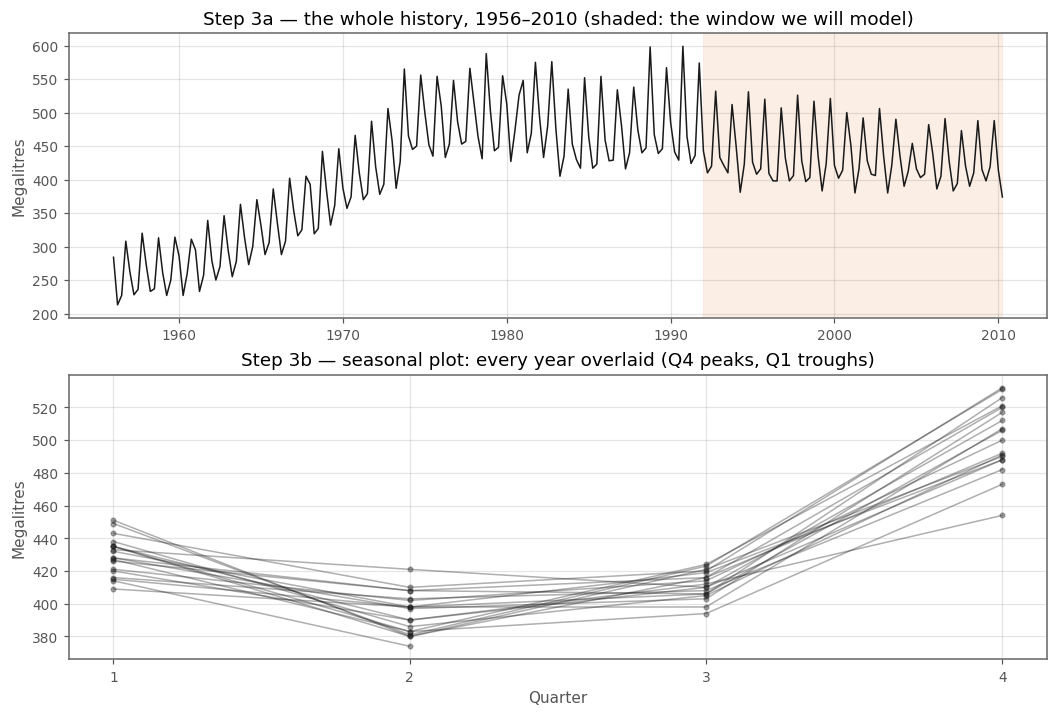

Observations from the plots:
  • A pronounced level shift and downward trend from the mid-1970s to the early 1990s.
  • Post-1992 the level is roughly stable -> we restrict modelling to 1992 onwards.
  • Strong, stable quarterly seasonality: Q4 high (summer/holidays), Q1 low.
  • No obvious outliers requiring expert explanation.


In [5]:
#  Demo 3, Step 3 — always plot the data first.

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=False)

full = aus_production[["ds", "Beer"]].dropna()
axes[0].plot(full["ds"], full["Beer"], color=C_HIST, lw=1.0)
axes[0].axvspan(pd.Timestamp("1992-01-01"), full["ds"].max(), color=C_ALT, alpha=0.10)
axes[0].set_title("Step 3a — the whole history, 1956–2010 (shaded: the window we will model)")
axes[0].set_ylabel("Megalitres")

# Seasonal view: one line per year, quarters on the x-axis.
sub = beer.assign(year=beer["ds"].dt.year, quarter=beer["ds"].dt.quarter)
for yr, grp in sub.groupby("year"):
    axes[1].plot(grp["quarter"], grp["Beer"], color=C_HIST, alpha=0.35, lw=1.0, marker="o", ms=3)
axes[1].set_title("Step 3b — seasonal plot: every year overlaid (Q4 peaks, Q1 troughs)")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Megalitres")
axes[1].set_xticks([1, 2, 3, 4])

plt.show()

print("Observations from the plots:")
print("  • A pronounced level shift and downward trend from the mid-1970s to the early 1990s.")
print("  • Post-1992 the level is roughly stable -> we restrict modelling to 1992 onwards.")
print("  • Strong, stable quarterly seasonality: Q4 high (summer/holidays), Q1 low.")
print("  • No obvious outliers requiring expert explanation.")


In [6]:
# Demo 3, Steps 4-5 — fit four benchmark methods on a training set, score them on a test set.

TEST_H = 10                                   # hold out the last 10 quarters (~2.5 years)
train, test = beer.iloc[:-TEST_H], beer.iloc[-TEST_H:]
y_train = train["Beer"].to_numpy(dtype=float)
y_test = test["Beer"].to_numpy(dtype=float)

print(f"train: {train['ds'].iloc[0].date()} to {train['ds'].iloc[-1].date()}  (n = {len(train)})")
print(f"test : {test['ds'].iloc[0].date()} to {test['ds'].iloc[-1].date()}  (n = {len(test)})\n")


def fc_mean(y, h):
    """Every future value equals the historical mean."""
    return np.repeat(y.mean(), h)


def fc_naive(y, h):
    """Every future value equals the last observation."""
    return np.repeat(y[-1], h)


def fc_seasonal_naive(y, h, m=M):
    """Every future value equals the value from the same season of the previous cycle."""
    steps = np.arange(1, h + 1)
    k = (steps - 1) // m
    return y[len(y) + steps - m * (k + 1) - 1]


def fc_drift(y, h):
    """Naive plus the average historical slope -- a line through the first and last points."""
    slope = (y[-1] - y[0]) / (len(y) - 1)
    return y[-1] + slope * np.arange(1, h + 1)


METHODS = {
    "Mean": fc_mean,
    "Naïve": fc_naive,
    "Seasonal naïve": fc_seasonal_naive,
    "Drift": fc_drift,
}

rows, curves = [], {}
for name, fn in METHODS.items():
    yhat = fn(y_train, TEST_H)
    curves[name] = yhat
    err = y_test - yhat
    rows.append({
        "Method": name,
        "RMSE": np.sqrt(np.mean(err ** 2)),
        "MAE": np.mean(np.abs(err)),
        "MAPE (%)": np.mean(np.abs(err / y_test)) * 100,
    })

accuracy = pd.DataFrame(rows).set_index("Method").sort_values("RMSE")
accuracy.round(2)


train: 1992-01-01 to 2007-10-01  (n = 64)
test : 2008-01-01 to 2010-04-01  (n = 10)


,RMSE,MAE,MAPE (%)
Method,,,
Seasonal naïve,14.31,13.40,3.17
Mean,38.45,34.83,8.28
Naïve,62.69,57.40,14.18
Drift,64.90,58.88,14.58


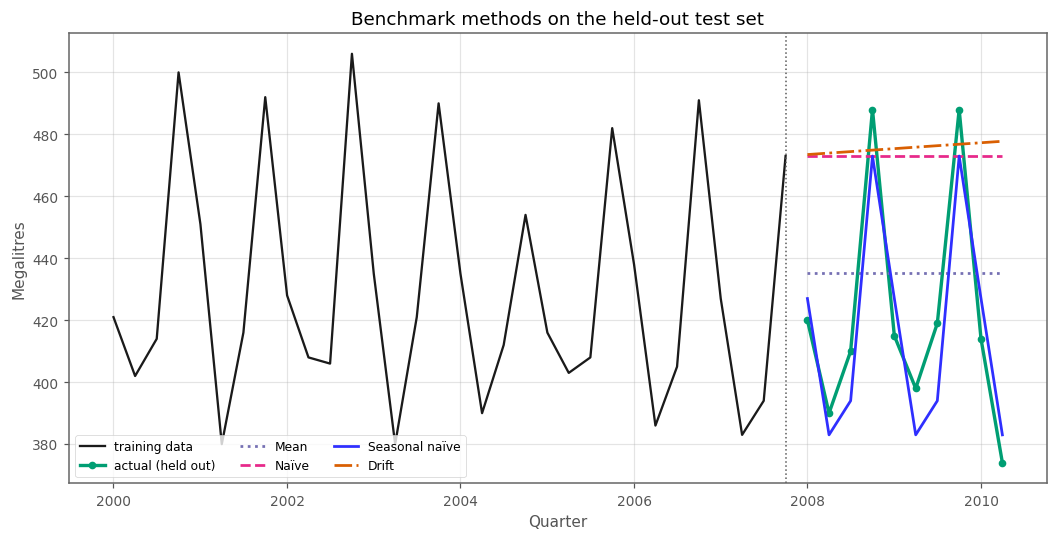

Lowest test RMSE: Seasonal naïve (14.31 megalitres, MAPE 3.2%)


In [7]:
# Demo 3, Step 5 (continued) — see *why* one method wins.

fig, ax = plt.subplots(figsize=(9.5, 4.8))
hist = train[train["ds"] >= "2000-01-01"]
ax.plot(hist["ds"], hist["Beer"], color=C_HIST, lw=1.5, label="training data")
ax.plot(test["ds"], y_test, color=C_ACT, lw=2.2, marker="o", ms=4, label="actual (held out)")

styles = {"Mean": ":", "Naïve": "--", "Seasonal naïve": "-", "Drift": "-."}
colors = {"Mean": "#7570b3", "Naïve": "#e7298a", "Seasonal naïve": C_FC, "Drift": C_ALT}
for name, yhat in curves.items():
    ax.plot(test["ds"], yhat, ls=styles[name], color=colors[name], lw=1.8, label=name)

ax.axvline(train["ds"].iloc[-1], color="0.35", ls=":", lw=1)
ax.set_title("Benchmark methods on the held-out test set")
ax.set_xlabel("Quarter")
ax.set_ylabel("Megalitres")
ax.legend(loc="lower left", ncol=3, frameon=True, fontsize=8)
plt.show()

best = accuracy["RMSE"].idxmin()
print(f"Lowest test RMSE: {best} ({accuracy.loc[best, 'RMSE']:.2f} megalitres, "
      f"MAPE {accuracy.loc[best, 'MAPE (%)']:.1f}%)")


**What Demo 3 is really teaching.** The seasonal naïve method wins because it is the only one of the
four that *encodes the dominant structure of the data* — the quarterly cycle. The mean and drift
methods have more "modelling" in them in a naive sense and lose badly.

This is the central discipline of the course: **any model you propose must beat the appropriate simple
benchmark on data it has never seen**. A method that cannot is not a model, it is decoration.

Two caveats we lift later:
- A single train/test split is a noisy estimate of accuracy. Lecture 5 introduces **time series
  cross-validation** (rolling origin evaluation) instead.
- MAPE is used above because it is familiar. It is badly behaved near zero and asymmetric between
  over- and under-forecasting; we will replace it with **MASE** and **scaled pinball / CRPS** losses.


---
# The statistical forecasting perspective  

This section reframes everything above, and it is the single most important idea in the lecture.

> The thing we are trying to forecast is **unknown**, so it is a **random variable**. A forecast is
> therefore not a number. It is a **probability distribution**.

Total sales next month could take a range of possible values, and until the month ends we do not know
which. It is only when sales close that the uncertainty resolves. Until then, sales are random.

Because the near future is usually more constrained by the present than the distant future is, the
forecast distribution **spreads out with the horizon**. This is not a modelling artifact; it is the
structure of the problem.

## Possible futures

When we forecast, we are estimating a distribution over *paths the world could take*. Demo 4 makes
this literal: we draw ten futures for Australian visitor arrivals, 2016–2025, each one a perfectly
plausible continuation of the same history.


estimated drift = 0.172 million visitors/year   residual sd = 0.189


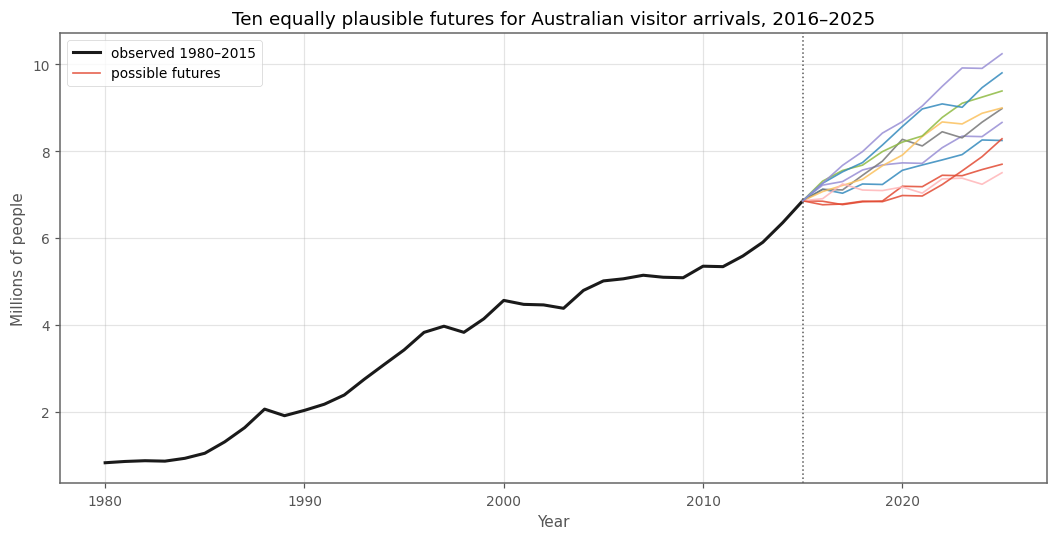

In [8]:
# Demo 4 — ten possible futures (cf. book Fig. 1.2).
#
# Model: random walk with drift, y_t = y_{t-1} + c + e_t, with residuals resampled (bootstrapped)
# from the observed history rather than assumed normal.

y = austa["Visitors"].to_numpy(dtype=float)
years = austa["Year"].to_numpy(dtype=int)
T = len(y)

drift = (y[-1] - y[0]) / (T - 1)              # average annual change
resid = np.diff(y) - drift                    # what the drift model failed to explain
print(f"estimated drift = {drift:.3f} million visitors/year   residual sd = {resid.std(ddof=1):.3f}")

H = 10
future_years = np.arange(years[-1] + 1, years[-1] + 1 + H)


def simulate_paths(n_paths, h=H, rng=RNG):
    """Bootstrap n_paths future trajectories from the drift model's residuals."""
    shocks = rng.choice(resid, size=(n_paths, h), replace=True)
    return y[-1] + np.cumsum(drift + shocks, axis=1)


paths = simulate_paths(10)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(years, y, color=C_HIST, lw=2.0, label="observed 1980–2015")
for i, path in enumerate(paths):
    ax.plot(np.r_[years[-1], future_years], np.r_[y[-1], path],
            lw=1.1, alpha=0.85, label="possible futures" if i == 0 else None)
ax.axvline(years[-1], color="0.35", ls=":", lw=1)
ax.set_title("Ten equally plausible futures for Australian visitor arrivals, 2016–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Millions of people")
ax.legend(loc="upper left", frameon=True)
plt.show()


Every one of those paths is consistent with the history. The spread among them **is** the forecast uncertainty.

## From possible futures to a point forecast and an interval

- The **point forecast** is the *middle* of the range of possible values — usually the **mean** of the
  forecast distribution. (Occasionally the median; the two coincide for symmetric distributions and
  differ importantly for skewed ones, e.g. after a log transform.)
- A **prediction interval** gives a range in which we expect the observation to lie with a specified
  probability. A **95 % prediction interval** contains a range of values that should include the actual future value with probability 0.95.

⚠️ A prediction interval is *not* a confidence interval. A confidence interval covers an unknown
**parameter**; a prediction interval covers an unknown **future observation**, and is always wider.


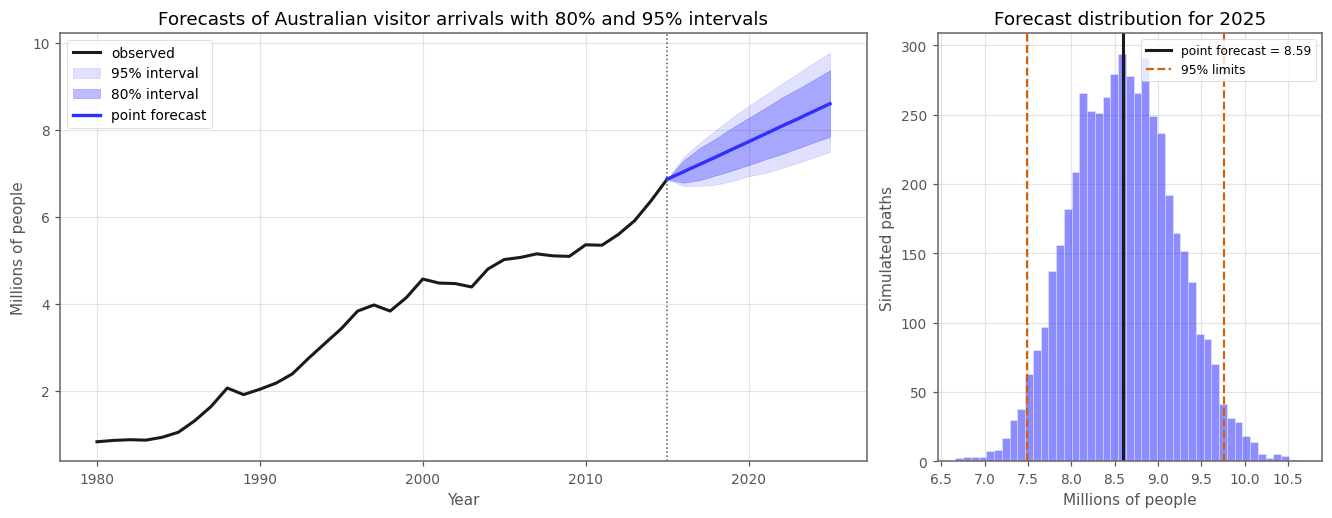


Interval width grows with the horizon:


,Point,Lo 80,Hi 80,Lo 95,Hi 95,Width 95
Year,,,,,,
2016,7.03,6.78,7.28,6.71,7.36,0.65
2017,7.20,6.84,7.57,6.71,7.69,0.99
2018,7.37,6.95,7.79,6.73,7.99,1.25
2019,7.55,7.06,8.04,6.82,8.28,1.46
2020,7.72,7.18,8.27,6.93,8.54,1.61
2021,7.89,7.31,8.49,7.00,8.79,1.79
2022,8.07,7.43,8.72,7.11,9.05,1.93
2023,8.24,7.57,8.93,7.23,9.28,2.05
2024,8.42,7.71,9.14,7.36,9.53,2.17


In [9]:
#  Demo 5 — the same model, now with 5,000 paths: point forecast + prediction intervals
#             (cf. book Fig. 1.3), plus the forecast distribution at a single horizon.

sims = simulate_paths(5000)

point = sims.mean(axis=0)
lo80, hi80 = np.percentile(sims, [10, 90], axis=0)
lo95, hi95 = np.percentile(sims, [2.5, 97.5], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6),
                         gridspec_kw={"width_ratios": [2.1, 1]})

band_years = np.r_[years[-1], future_years]          # anchor the fan at the last observation
ax = axes[0]
ax.plot(years, y, color=C_HIST, lw=2.0, label="observed")
ax.fill_between(band_years, np.r_[y[-1], lo95], np.r_[y[-1], hi95],
                color=C_FC, alpha=0.15, label="95% interval")
ax.fill_between(band_years, np.r_[y[-1], lo80], np.r_[y[-1], hi80],
                color=C_FC, alpha=0.32, label="80% interval")
ax.plot(np.r_[years[-1], future_years], np.r_[y[-1], point], color=C_FC, lw=2.2,
        label="point forecast")
ax.axvline(years[-1], color="0.35", ls=":", lw=1)
ax.set_title("Forecasts of Australian visitor arrivals with 80% and 95% intervals")
ax.set_xlabel("Year")
ax.set_ylabel("Millions of people")
ax.legend(loc="upper left", frameon=True)

# The forecast *distribution* at the final horizon -- the object the left panel summarises.
ax = axes[1]
final = sims[:, -1]
ax.hist(final, bins=45, color=C_FC, alpha=0.55, edgecolor="white", lw=0.4)
ax.axvline(final.mean(), color=C_HIST, lw=2.0, label=f"point forecast = {final.mean():.2f}")
ax.axvline(np.percentile(final, 2.5), color=C_ALT, lw=1.4, ls="--", label="95% limits")
ax.axvline(np.percentile(final, 97.5), color=C_ALT, lw=1.4, ls="--")
ax.set_title(f"Forecast distribution for {future_years[-1]}")
ax.set_xlabel("Millions of people")
ax.set_ylabel("Simulated paths")
ax.legend(loc="upper right", fontsize=8, frameon=True)

plt.show()

summary = pd.DataFrame({
    "Year": future_years,
    "Point": point, "Lo 80": lo80, "Hi 80": hi80, "Lo 95": lo95, "Hi 95": hi95,
}).set_index("Year")
print("\nInterval width grows with the horizon:")
summary.assign(**{"Width 95": summary["Hi 95"] - summary["Lo 95"]}).round(2)


The left panel is a *summary* of the right panel — repeated at every horizon. Whenever you see a fan
chart, remember there is a full distribution hiding behind each vertical slice.

## Notation

We use a subscript $t$ for time. $y_t$ is the observation at time $t$.

Suppose all the information we have observed is collected in a set $\mathcal{I}$. Then

$$y_t \mid \mathcal{I}$$

means "the random variable $y_t$ **given** what we know in $\mathcal{I}$." The set of values this
random variable could take, along with their relative probabilities, is the **forecast distribution**.

| Symbol | Meaning |
|---|---|
| $y_t$ | the observation at time $t$ |
| $\hat{y}_t$ | the **point forecast** — the *average* of the possible values of $y_t$ (the mean of the forecast distribution) |
| $\hat{y}_{t\mid t-1}$ | the forecast of $y_t$ using **all previous observations** $y_1,\dots,y_{t-1}$ — a **one-step** forecast |
| $\hat{y}_{T+h\mid T}$ | the **$h$-step forecast** of $y_{T+h}$, made using $y_1,\dots,y_T$ |
| $T$ | the index of the last observation (the **forecast origin**) |
| $h$ | the **forecast horizon** |

Writing $\hat{y}_{T+h\mid T}$ rather than $\hat{y}_{T+h}$ is not pedantry: it records **what
information the forecast was allowed to use**. Almost every catastrophic result in applied forecasting
comes from a model that quietly used information from after the forecast origin.


---
## Optional — the book's own toolchain  <span style="color:#888">(run outside class)</span>

The book uses the **nixtlaverse**: `statsforecast` for models and `utilsforecast` for plotting. Its
data convention is a long DataFrame with three columns:

| Column | Meaning |
|---|---|
| `unique_id` | series identifier (so one DataFrame can hold thousands of series) |
| `ds` | timestamp |
| `y` | value |

The cell below reproduces Demo 5 with `AutoETS` — automatic exponential smoothing, Chapter 8 material.
It is wrapped so the notebook still runs end to end if the packages are absent.

```bash
pip install statsforecast utilsforecast
```


In [10]:
# Optional: the book's workflow. Skipped cleanly if statsforecast is not installed.
try:
    import os
    os.environ["NIXTLA_ID_AS_COL"] = "true"
    from statsforecast import StatsForecast
    from statsforecast.models import AutoETS

    austa_long = pd.DataFrame({
        "unique_id": "austa",
        "ds": pd.to_datetime(austa["Year"].astype(str) + "-01-01"),
        "y": austa["Visitors"].to_numpy(dtype=float),
    })

    sf = StatsForecast(models=[AutoETS(season_length=1)], freq="YS")
    sf.fit(austa_long)
    fc_ets = sf.predict(h=10, level=[80, 95])

    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.plot(austa_long["ds"], austa_long["y"], color=C_HIST, lw=2.0, label="observed")
    ax.fill_between(fc_ets["ds"], fc_ets["AutoETS-lo-95"], fc_ets["AutoETS-hi-95"],
                    color=C_FC, alpha=0.15, label="95% interval")
    ax.fill_between(fc_ets["ds"], fc_ets["AutoETS-lo-80"], fc_ets["AutoETS-hi-80"],
                    color=C_FC, alpha=0.32, label="80% interval")
    ax.plot(fc_ets["ds"], fc_ets["AutoETS"], color=C_FC, lw=2.2, label="AutoETS point forecast")
    ax.set_title("AutoETS forecasts of Australian visitor arrivals (book toolchain)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Millions of people")
    ax.legend(loc="upper left", frameon=True)
    plt.show()

    print(fc_ets.round(2).to_string(index=False))
except ImportError:
    print("statsforecast / utilsforecast not installed - skipping.")
    print("Install with:  pip install statsforecast utilsforecast")


statsforecast / utilsforecast not installed - skipping.
Install with:  pip install statsforecast utilsforecast


---
# Wrap-up 

## Ten sentences worth keeping

1. Predictability depends on **understanding, data, stability of the mechanism, and feedback** — not on
   how sophisticated your model is.
2. Forecasting does **not** require an unchanging world; it requires that *the pattern of change*
   persists.
3. A **goal** is not a forecast, and a **forecast** is not a plan. Never revise a forecast to please a
   goal; revise the plan.
4. The **horizon** determines the aggregation level, the model class, and the achievable accuracy. Fix
   it first.
5. Decide **what** to forecast, **how far ahead**, **how often**, and **for whom** before you model.
6. Quantitative forecasting requires numerical history **and** the assumption that past patterns
   continue. State the assumption out loud.
7. **Time series models** deliberately ignore causes and often win, because predictors must themselves
   be forecast, and prediction is not explanation.
8. The five steps: **define, gather, explore, fit & compare, evaluate**. Step 1 is the hardest;
   step 3 always begins with a plot.
9. A forecast is a **probability distribution**. The point forecast is its mean; the prediction interval
   is the honest part of the answer.
10. $\hat{y}_{T+h\mid T}$. The conditioning bar is a promise about what information you used. Keep it.

